# Dynamic Facial Expression Recognition with Images

In [1]:
name_of_this_notebook = 'late_fusion_avg.ipynb'

In [2]:
# import os

# os.environ['PYTHONHASHSEED'] = '7'

In [3]:
!echo "${PYTHONUNBUFFERED}"
!echo "${TF_CPP_MIN_LOG_LEVEL}"
!echo "${TF_FORCE_GPU_ALLOW_GROWTH}"
!echo "${TF_GPU_ALLOCATOR}"
!echo "${PYTHONHASHSEED}"


2
true
cuda_malloc_async



In [4]:
import re
import ipykernel.iostream

TF_LOG_FILTER_PATTERNS = [
    r'ptx\d+.*is not a recognized feature for this target',
    r'is not a recognized feature for this target \(ignoring feature\)',
    r'\(ignoring feature\)',
    r'successful NUMA node read from SysFS had negative value \(-1\)',
    r'gpu_timer\.cc:114\] Skipping the delay kernel, measurement accuracy will be reduced',
]

KERAS_PROGRESS_PATTERNS = [
    r'ms/step',
    r's/step',
    r'ETA:',
    r'\d+/\d+ \[',   # 12/64 [===>...]
]

_original_write = ipykernel.iostream.OutStream.write

def _filtered_write(self, msg, *args, **kwargs):
    text = str(msg)

    if any(re.search(p, text) for p in KERAS_PROGRESS_PATTERNS):
        _original_write(self, text, *args, **kwargs)
        return

    buf = getattr(self, '_tf_log_filter_buf', '')
    buf += text

    if '\n' not in buf:
        setattr(self, '_tf_log_filter_buf', buf)
        return

    lines = buf.splitlines(keepends=True)
    if not buf.endswith('\n'):
        incomplete = lines.pop()
    else:
        incomplete = ''

    for line in lines:
        if any(re.search(p, line) for p in TF_LOG_FILTER_PATTERNS):
            continue
        _original_write(self, line, *args, **kwargs)

    setattr(self, '_tf_log_filter_buf', incomplete)

ipykernel.iostream.OutStream.write = _filtered_write

print('Notebook log filter installed (targeted, keeps Keras steps).')

Notebook log filter installed (targeted, keeps Keras steps).


In [5]:
import keras

keras.mixed_precision.set_global_policy('mixed_float16')

2025-11-12 12:06:21.834444: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-12 12:06:21.843126: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-12 12:06:21.846026: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
# Ensure Determinism
import random
import numpy as np
import tensorflow as tf

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
# tf.config.experimental.enable_op_determinism()

In [7]:
# Ensure GPU works as expected
import json

print('TensorFlow Version:', tf.__version__, ';', 'Keras Version:', keras.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Number of GPUs detected: {len(gpus)}')
    for gpu in gpus:
        device_details = tf.config.experimental.get_device_details(gpu)
        print(f'Physical Device: {gpu.name}')
        print(f'Name: {device_details["device_name"]}')
        print(f'Compute Capability: {device_details["compute_capability"]}')
else:
    print('No GPUs were detected.')

print(json.dumps(tf.sysconfig.get_build_info(), indent=2))

TensorFlow Version: 2.17.0 ; Keras Version: 3.12.0
Number of GPUs detected: 1
Physical Device: /physical_device:GPU:0
Name: NVIDIA GeForce RTX 5090
Compute Capability: (12, 0)
{
  "cpu_compiler": "/opt/rh/gcc-toolset-11/root/usr/bin/gcc",
  "cuda_compute_capabilities": [
    "sm_100",
    "sm_120",
    "sm_75",
    "sm_80",
    "sm_86",
    "compute_90"
  ],
  "cuda_version": "12.8",
  "cudnn_version": "9",
  "is_cuda_build": true,
  "is_rocm_build": false,
  "is_tensorrt_build": true
}


In [8]:
SEQUENCE_LENGTH = 30
IMAGE_SIZE = (224, 224, 3)
BATCH_SIZE = 32
LR = 1e-3

experiment_name = f'{name_of_this_notebook[:-6]}-seed-{SEED}'

## Prepare Data

In [9]:
from pathlib import Path

dataset_path = Path(r'/workspace/datasets')

emotion_to_id = {
    'Anger': 0,
    'Disgust': 1,
    'Fear': 2,
    'Happiness': 3,
    'Neutral': 4,
    'Sadness': 5,
    'Surprise': 6,
}

### Prepare FEA Sequences

In [10]:
import pandas as pd

fea_dataset_path = dataset_path / 'emoji-hero-vr-db-dfea-as-csv'

fea_train_df = pd.read_csv(str(fea_dataset_path / 'training_set.csv'))
print('fea_train_df.shape:', fea_train_df.shape)

fea_val_df = pd.read_csv(str(fea_dataset_path / 'validation_set.csv'))
print('fea_val_df.shape:', fea_val_df.shape)

fea_test_df = pd.read_csv(str(fea_dataset_path / 'test_set.csv'))
print('test_df.shape:', fea_test_df.shape)
print('\nColumns and Data Types:\n', fea_test_df.dtypes)

fea_train_df.shape: (28920, 66)
fea_val_df.shape: (11550, 66)
test_df.shape: (11340, 66)

Columns and Data Types:
 sequence_id         object
timestamp            int64
BrowLowererL       float64
BrowLowererR       float64
CheekPuffL         float64
                    ...   
UpperLidRaiserL    float64
UpperLidRaiserR    float64
UpperLipRaiserL    float64
UpperLipRaiserR    float64
Label                int64
Length: 66, dtype: object


In [11]:
def prepare_data(df: pd.DataFrame) -> dict[str, tuple[list, list, list]]:
    
    df_sorted = df.sort_values(["sequence_id", "timestamp"])
    
    sequences = dict()

    for sequence_id, group in df_sorted.groupby('sequence_id', sort=False):
        timestamps = group.iloc[:, 1].tolist()  # Select timestamp column
        features = group.iloc[:, 2:-1].values.tolist()  # Select all feature columns
        label = group.iloc[0, -1].tolist()  # Select one label per group
        sequences[sequence_id] = (timestamps, features, label)  

    return sequences


fea_sequences_train = prepare_data(fea_train_df)
fea_sequences_val = prepare_data(fea_val_df)
fea_sequences_test = prepare_data(fea_test_df)

### Combine FEA Sequences with Image Sequences

In [12]:
image_dataset_path = dataset_path / 'emoji-hero-vr-db-di'
image_train_set_path = image_dataset_path / 'training_set'
image_val_set_path = image_dataset_path / 'validation_set'
image_test_set_path = image_dataset_path / 'test_set'

In [13]:
def load_image_sequence_paths(image_dataset_path: Path, fea_sequences_d: dict[str, tuple[np.ndarray, int]]):
    
    print(f'\nLoading images from: {image_dataset_path}\n')
    
    fea_sequences = []
    img_sequence_paths = []
    labels = []

    for class_dir in image_dataset_path.iterdir():
        label = emotion_to_id[class_dir.name]
        for sequence_dir in class_dir.iterdir():
            sequence_id = sequence_dir.name[:-2]
            matching_fea_sequence = fea_sequences_d.get(sequence_id)
            if matching_fea_sequence is None:
                print(f'Could not find FEA sequences for image sequence {sequence_dir.name}')
                continue
            else:
                fea_timestamps = matching_fea_sequence[0]
                fea_features = matching_fea_sequence[1]
                feas = []
                image_paths = []
                
                for i, img_path in enumerate(sorted(sequence_dir.iterdir())):
                    fea_timestamp = int(fea_timestamps[i])
                    img_timestamp = int(img_path.name.split('-')[0])
                    if fea_timestamp != img_timestamp:
                        print(f'Image and FEA timestamps do not match for image path: {img_path}')
                    else:
                        feas.append(fea_features[i])
                        image_paths.append(str(img_path))

                fea_sequences.append(feas)
                img_sequence_paths.append(image_paths)
                labels.append(label)
        
    print(f'\nFound {len(img_sequence_paths)} image sequences with corresponding FEA sequences in {image_dataset_path}\n')
    return fea_sequences, img_sequence_paths, labels

In [14]:
train_fea_sequences, train_img_sequences, train_labels = load_image_sequence_paths(image_train_set_path, fea_sequences_train)
val_fea_sequences, val_img_sequences, val_labels = load_image_sequence_paths(image_val_set_path, fea_sequences_val)
test_fea_sequences, test_img_sequences, test_labels = load_image_sequence_paths(image_test_set_path, fea_sequences_test)


Loading images from: /workspace/datasets/emoji-hero-vr-db-di/training_set

Could not find FEA sequences for image sequence 1700566738359-0-7-4-0-1-1
Could not find FEA sequences for image sequence 1700566462521-0-7-2-4-1-1
Could not find FEA sequences for image sequence 1701188073794-0-31-2-5-1-1
Could not find FEA sequences for image sequence 1700566589454-0-7-3-9-1-1
Could not find FEA sequences for image sequence 1700566738359-0-7-4-0-1-0
Could not find FEA sequences for image sequence 1701188073794-0-31-2-5-1-0
Could not find FEA sequences for image sequence 1700566589454-0-7-3-9-1-0
Could not find FEA sequences for image sequence 1700566462521-0-7-2-4-1-0
Could not find FEA sequences for image sequence 1700566780730-0-7-4-24-3-1
Could not find FEA sequences for image sequence 1700566593020-0-7-3-11-3-1
Could not find FEA sequences for image sequence 1700566375750-0-7-1-6-3-1
Could not find FEA sequences for image sequence 1700566780730-0-7-4-24-3-0
Could not find FEA sequences fo

### Prepare Datasets

In [15]:
def parse_image(filename: str) -> tf.Tensor:
    image_string_tensor = tf.io.read_file(filename)
    image_int_tensor = tf.io.decode_jpeg(image_string_tensor, channels=IMAGE_SIZE[2])
    return image_int_tensor


def load_sequence(images_paths: tf.Tensor) -> tf.Tensor:
    images = tf.map_fn(parse_image, images_paths, fn_output_signature=tf.uint8)
    # images = tf.ensure_shape(images, [SEQUENCE_LENGTH, *IMAGE_SIZE])
    return images


def create_combined_dataset(fea_sequences:list[list[float]], img_sequence_paths:list[list[str]], labels: list[int], training:bool, batch_size: int) -> tf.data.Dataset:
    
    fea_sequences = tf.constant(np.array(fea_sequences), dtype=tf.float32)
    img_sequence_paths = tf.constant(np.array(img_sequence_paths), dtype=tf.string)
    labels = tf.constant(labels, dtype=tf.int32)
    
    ds = tf.data.Dataset.from_tensor_slices((fea_sequences, img_sequence_paths, labels))

    # In this notebook, we do not train at all, so shuffling is unnecessary
    # if training:
    #     ds = ds.shuffle(len(labels), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda feas, image_paths, labels: ((feas, load_sequence(image_paths)), labels), num_parallel_calls=tf.data.AUTOTUNE    
    )

    ds = ds.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

    return ds


In [16]:
train_ds = create_combined_dataset(train_fea_sequences, train_img_sequences, train_labels, training=True, batch_size=BATCH_SIZE)

In [17]:
val_ds = create_combined_dataset(val_fea_sequences, val_img_sequences, val_labels, training=False, batch_size=BATCH_SIZE)

In [18]:
test_ds = create_combined_dataset(test_fea_sequences, test_img_sequences, test_labels, training=False, batch_size=BATCH_SIZE)

### Prepare Class Frequencies for Loss Function

In [19]:
from collections import Counter


id_to_emotion = {v: k for k, v in emotion_to_id.items()}


def compute_class_frequencies(labels: list[int]) -> dict[int, int]:  
    class_frequencies = dict(Counter(labels))
    for label, frequency in sorted(class_frequencies.items()):
        print(f'{label} - {id_to_emotion[label]:<9} : {frequency:>8}')
    print(f'===\nFound {sum(class_frequencies.values())} samples in total.')
    return class_frequencies


def compute_class_weights(class_frequencies: dict[int, int]) -> dict[int, float]:
    inverse_frequencies = {k: 1/v for k, v in class_frequencies.items()}
    num_classes = len(class_frequencies)
    inverse_sum = sum(inverse_frequencies.values())
    class_weights = {k: (v * (num_classes / inverse_sum)) for k, v in sorted(inverse_frequencies.items())}
    return class_weights

In [20]:
print('---TRAINING SET---')
class_frequencies = compute_class_frequencies(train_labels)
class_weights = compute_class_weights(class_frequencies)
print(f'\nClass Weights:\n {class_weights}')

---TRAINING SET---
0 - Anger     :      132
1 - Disgust   :      204
2 - Fear      :      210
3 - Happiness :      382
4 - Neutral   :      394
5 - Sadness   :      262
6 - Surprise  :      344
===
Found 1928 samples in total.

Class Weights:
 {0: 1.8211414828477055, 1: 1.1783856653720446, 2: 1.144717503504272, 3: 0.6292949626594165, 4: 0.6101286186190281, 5: 0.9175216631141111, 6: 0.6988101038834218}


In [21]:
print('---VALIDATION SET---')
compute_class_frequencies(val_labels)

---VALIDATION SET---
0 - Anger     :      110
1 - Disgust   :      110
2 - Fear      :      110
3 - Happiness :      110
4 - Neutral   :      110
5 - Sadness   :      110
6 - Surprise  :      110
===
Found 770 samples in total.


{1: 110, 3: 110, 5: 110, 2: 110, 4: 110, 0: 110, 6: 110}

In [22]:
compute_class_frequencies(test_labels)

0 - Anger     :      108
1 - Disgust   :      108
2 - Fear      :      108
3 - Happiness :      108
4 - Neutral   :      108
5 - Sadness   :      108
6 - Surprise  :      108
===
Found 756 samples in total.


{1: 108, 3: 108, 5: 108, 2: 108, 4: 108, 0: 108, 6: 108}

## Define Network Architecture

### Load Pretrained Models

In [23]:
from keras.models import load_model

models_base_path = Path() / 'models'
fea_model_path = models_base_path / 'fea_model.keras'
img_model_path = models_base_path / 'image_model.keras'

fea_model = load_model(str(fea_model_path))
img_model = load_model(str(img_model_path))

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 20 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2025-11-12 12:06:36.838405: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 260 variables whereas the saved optimizer has 256 variables. 
  saveable.load_own_va

In [24]:
fea_test_dataset = test_ds.map(lambda inputs, labels: (inputs[0], labels))
fea_loss, fea_accuracy = fea_model.evaluate(fea_test_dataset)
print(f'FEA Model - Test Loss: {fea_loss}, Test Accuracy: {fea_accuracy}')

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7831 - loss: 0.8472
FEA Model - Test Loss: 0.8472196459770203, Test Accuracy: 0.7830687761306763


In [25]:
img_test_dataset = test_ds.map(lambda inputs, labels: (inputs[1], labels))
img_loss, img_accuracy = img_model.evaluate(img_test_dataset)
print(f'Image Model - Test Loss: {img_loss}, Test Accuracy: {img_accuracy}')

24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 261ms/step - accuracy: 0.7169 - loss: 0.9879
Image Model - Test Loss: 0.9878646731376648, Test Accuracy: 0.7169312238693237


### Build Multimodal Model

In [26]:
from keras.layers import Average
from keras.layers import Input
from keras.models import Model

NUM_FEA_FEATURES = 63

fea_input = Input(shape=(SEQUENCE_LENGTH, NUM_FEA_FEATURES), name='fea_input')
image_input = Input(shape=(SEQUENCE_LENGTH, *IMAGE_SIZE), name='image_input')

fea_output = fea_model(fea_input)
image_output = img_model(image_input)

img_model.trainable = False
fea_model.trainable = False

combined_preds = Average()([fea_output, image_output])

combined_model = Model(inputs=[fea_input, image_input], outputs=combined_preds)

combined_model.trainable = False

combined_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fea_input           │ (None, 30, 63)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 30, 224,   │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 7)         │    115,846 │ fea_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DynamicEfficientNet │ (None, 7)         │  6,087,607 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average (Average)   │ (None, 7)         │          0 │ functional[0][0], │
│                     │                   │            │ DynamicEfficient… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,203,453 (23.66 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,203,453 (23.66 MB)

### Compile the Model

In [27]:
from datetime import datetime
from keras.optimizers import Adam

timestamp = datetime.now().strftime("%Y%m%d-%H%M")
checkpoint_dir = Path(f'{timestamp}-{experiment_name}')
checkpoint_dir.mkdir(parents=True, exist_ok=True)

optimizer = Adam(learning_rate=LR)

combined_model.compile(optimizer=optimizer,
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"],
                       jit_compile=False)

## Save Model

In [28]:
combined_model.save(str(checkpoint_dir / 'average_model.keras'))

## Evaluate Model

### Training

In [29]:
from sklearn.metrics import classification_report

train_y_pred_vectors = combined_model.predict(train_ds)
train_y_pred = np.argmax(train_y_pred_vectors, axis=1)
train_y_true = np.concatenate([y for _, y in train_ds], axis=0)

train_report = classification_report(train_y_true, train_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(train_report)

train_acc = classification_report(train_y_true, train_y_pred, target_names=emotion_to_id.keys(), digits=4, output_dict=True)['accuracy']

61/61 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step  
              precision    recall  f1-score   support

       Anger     0.9925    1.0000    0.9962       132
     Disgust     1.0000    0.9951    0.9975       204
        Fear     0.9858    0.9952    0.9905       210
   Happiness     0.9974    1.0000    0.9987       382
     Neutral     0.9975    0.9975    0.9975       394
     Sadness     1.0000    1.0000    1.0000       262
    Surprise     0.9971    0.9884    0.9927       344

    accuracy                         0.9964      1928
   macro avg     0.9957    0.9966    0.9962      1928
weighted avg     0.9964    0.9964    0.9964      1928



[[132   0   0   0   0   0   0]
 [  1 203   0   0   0   0   0]
 [  0   0 209   0   0   0   1]
 [  0   0   0 382   0   0   0]
 [  0   0   0   1 393   0   0]
 [  0   0   0   0   0 262   0]
 [  0   0   3   0   1   0 340]]


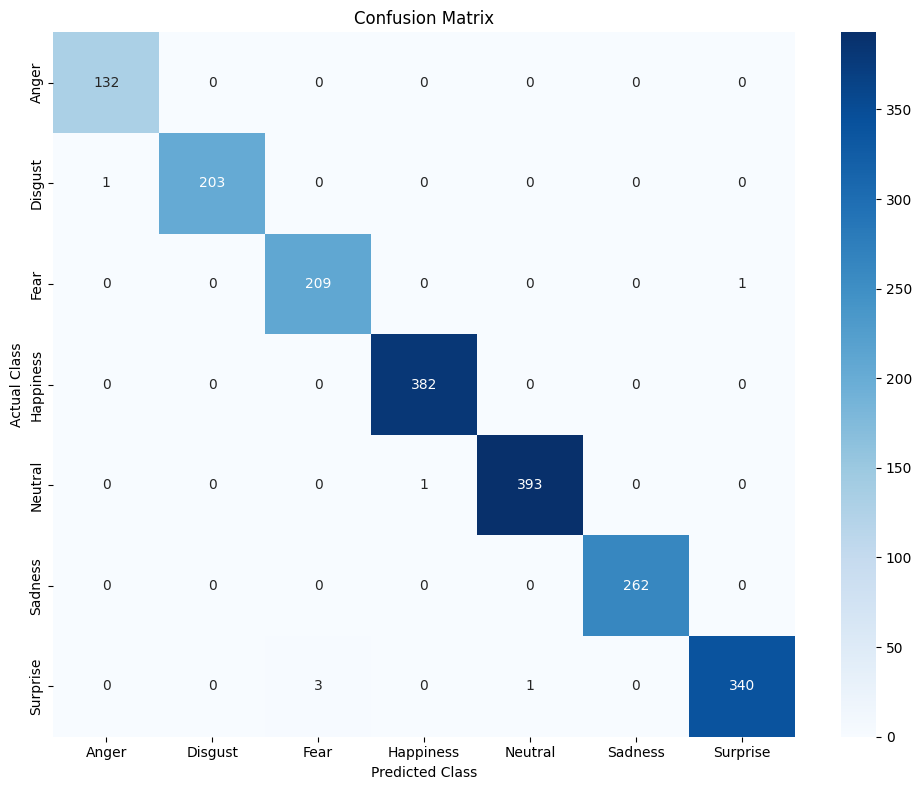

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


def plot_confusion_matrix(y_true, y_pred):
    class_names = emotion_to_id.keys()

    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

    return fig


train_cm_figure = plot_confusion_matrix(train_y_true, train_y_pred)

### Validation

In [30]:
val_y_pred_vectors = combined_model.predict(val_ds)
val_y_pred = np.argmax(val_y_pred_vectors, axis=1)
val_y_true = np.concatenate([y for _, y in val_ds], axis=0)

val_report = classification_report(val_y_true, val_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(val_report)

val_acc = classification_report(val_y_true, val_y_pred, target_names=emotion_to_id.keys(), digits=4, output_dict=True)['accuracy']

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 265ms/step
              precision    recall  f1-score   support

       Anger     0.7838    0.5273    0.6304       110
     Disgust     0.7263    0.6273    0.6732       110
        Fear     0.8700    0.7909    0.8286       110
   Happiness     0.8480    0.9636    0.9021       110
     Neutral     0.8571    0.9818    0.9153       110
     Sadness     0.7254    0.9364    0.8175       110
    Surprise     0.9630    0.9455    0.9541       110

    accuracy                         0.8247       770
   macro avg     0.8248    0.8247    0.8173       770
weighted avg     0.8248    0.8247    0.8173       770



[[ 58  19   0   4   9  20   0]
 [ 11  69   7   5   0  18   0]
 [  0   5  87  10   4   0   4]
 [  1   1   0 106   2   0   0]
 [  0   1   0   0 108   1   0]
 [  4   0   0   0   3 103   0]
 [  0   0   6   0   0   0 104]]


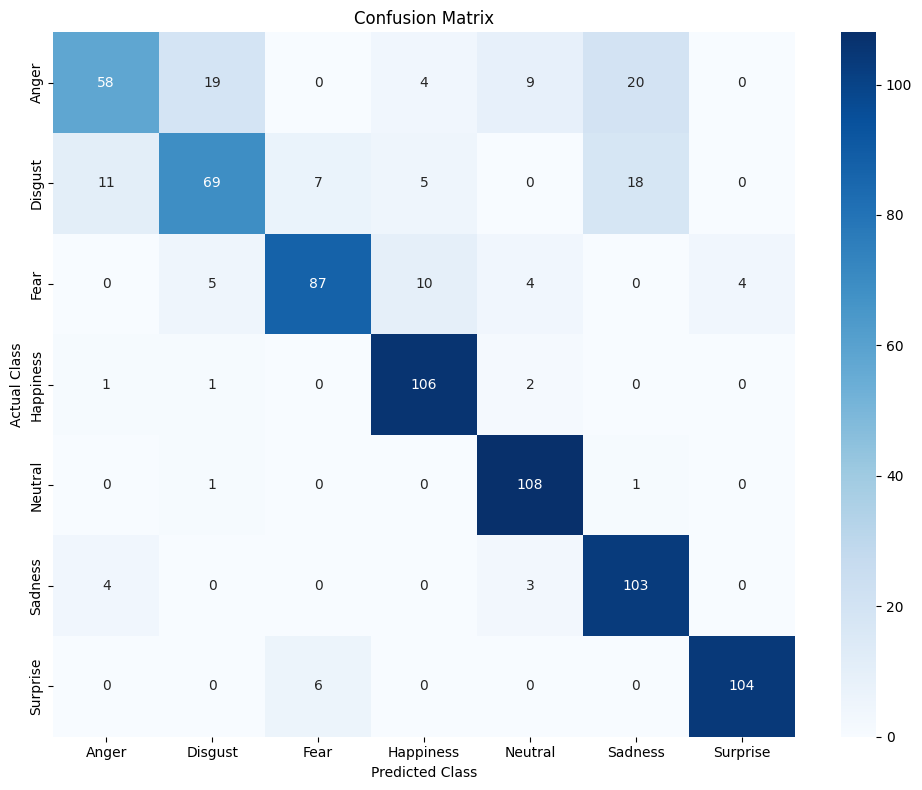

In [34]:
val_cm_figure = plot_confusion_matrix(val_y_true, val_y_pred)

### Test

In [31]:
test_y_pred_vectors = combined_model.predict(test_ds)
test_y_pred = np.argmax(test_y_pred_vectors, axis=1)
test_y_true = np.concatenate([y for _, y in test_ds], axis=0)

test_report = classification_report(test_y_true, test_y_pred, target_names=emotion_to_id.keys(), digits=4)
print(test_report)

test_acc = classification_report(test_y_true, test_y_pred, target_names=emotion_to_id.keys(), digits=4, output_dict=True)['accuracy']

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step
              precision    recall  f1-score   support

       Anger     0.7792    0.5556    0.6486       108
     Disgust     0.5789    0.5093    0.5419       108
        Fear     0.7826    0.6667    0.7200       108
   Happiness     0.6923    1.0000    0.8182       108
     Neutral     0.8220    0.8981    0.8584       108
     Sadness     0.9189    0.9444    0.9315       108
    Surprise     0.9252    0.9167    0.9209       108

    accuracy                         0.7844       756
   macro avg     0.7856    0.7844    0.7771       756
weighted avg     0.7856    0.7844    0.7771       756



[[ 60  31   1  10   5   1   0]
 [  9  55   7  28   2   5   2]
 [  0   9  72   7  13   1   6]
 [  0   0   0 108   0   0   0]
 [  3   0   3   3  97   2   0]
 [  5   0   0   0   1 102   0]
 [  0   0   9   0   0   0  99]]


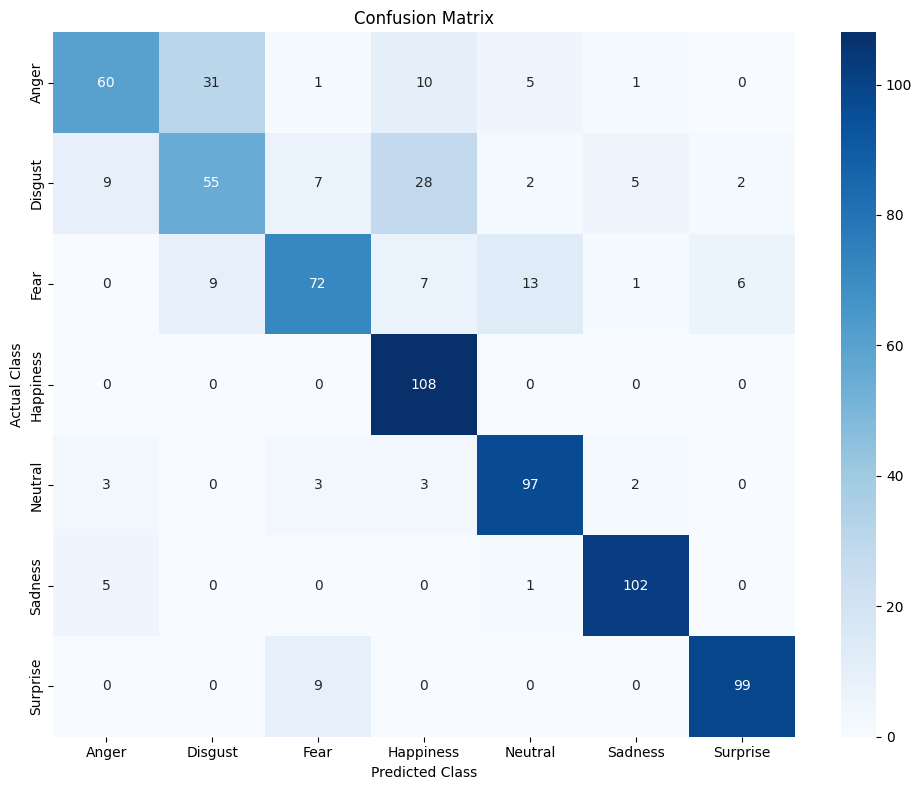

In [35]:
test_cm_figure = plot_confusion_matrix(test_y_true, test_y_pred)

In [36]:
def save_evaluation_results(report, cm_figure, checkpoint_dir):
    with (checkpoint_dir / 'classification_report.txt').open(mode='w') as f:
        f.write(report)
    cm_figure.savefig(str(checkpoint_dir / 'confusion_matrix.png'))


save_evaluation_results(test_report, test_cm_figure, checkpoint_dir)

In [37]:
import time

time.sleep(3)

In [40]:
def add_accuracies_to_checkpoint_dir_name(checkpoint_dir, train_acc, val_acc, test_acc):
    new_name = checkpoint_dir.name + f'_train_{str(train_acc)[2:6]}_val_{str(val_acc)[2:6]}_test_{str(test_acc)[2:6]}'
    new_path = checkpoint_dir.parent / new_name
    checkpoint_dir.rename(new_path)
    return new_path


new_checkpoint_dir = add_accuracies_to_checkpoint_dir_name(checkpoint_dir, train_acc, val_acc, test_acc)

In [ ]:
time.sleep(30)

In [41]:
import shutil

shutil.copy2((Path() / name_of_this_notebook), (new_checkpoint_dir / name_of_this_notebook))

PosixPath('20251112-1208-late_fusion_avg-seed-13_train_9963_val_8246_test_7843/late_fusion_avg.ipynb')